# L2S for Job-Shop Scheduling — Colab Notebook

A from-scratch, **single-file PyTorch** re-implementation of the *Learning-to-Search* (L2S)
improvement-heuristic for the Job-Shop Scheduling Problem (JSSP), inspired by:

> Cong Zhang et al., *Deep Reinforcement Learning Guided Improvement Heuristic for
> Job Shop Scheduling*, ICLR 2024.

**What L2S does.** Instead of *constructing* a schedule operation-by-operation, L2S starts
from a **complete** solution and *learns to search*: at every step a GNN policy picks a local
move (an operation-pair swap inside a *critical block*), the makespan is recomputed, and the
process repeats for `T` steps. The agent is rewarded for improving the best solution found.

**The 5 pillars (and where they live in this notebook):**
1. **Local-search loop** → `Environment` (Cells 8-9)
2. **N5 neighbourhood** (critical blocks) → Cell 6
3. **Graph embedding** (GIN-based TPM + multi-head GAT-based CAM) → Cell 10
4. **MDP** (state = complete-solution graph, reward = step improvement) → Cell 8
5. **Batched GPU message-passing evaluator** (EST forward + LST backward) → Cell 5

**What this version adds on top of the basic prototype:**
- **Multi-head attention** in the GAT (CAM) layers for richer context embeddings.
- **Batched GPU message-passing** for both EST (forward) and LST (backward), replacing
  the sequential NumPy loop as the live node-feature source.
- **Actor-critic** training (n-step returns with a learned value baseline).
- **Vectorised state construction** (conjunctive adjacency built once per env).
- **Model checkpointing** (`l2s_jssp_policy.pt`).
- **Curriculum training** (Cell 13b): sequential fine-tuning on 15×15 → 20×20 → 30×30 → 50×20.
- **Evaluation on classic benchmarks** (FT, LA, ABZ, TA) with format verification,
  instance visualization, and comparison against **SPT, LPT, FDD, MWKR, SBT**
  (Shifting Bottleneck Heuristic) baselines, plus **multi-sample** L2S evaluation
  (best-of-k stochastic rollouts) (Cells 14-17).

> Only `torch`, `numpy`, `matplotlib` are used (pre-installed on Colab). Defaults are sized
> for **Colab Free Tier**: full Run-All finishes in well under ~25 minutes on CPU/T4.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Cell 2 — Environment check (Colab has torch/numpy/matplotlib pre-installed)
import sys, torch, numpy as np
print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("NumPy  :", np.__version__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)


Python : 3.12.13
PyTorch: 2.11.0+cu128
NumPy  : 2.0.2
Device : cuda


In [4]:
# Cell 3 — Imports, seeding, and global configuration
import math, random, time, os
from dataclasses import dataclass, field
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@dataclass
class Config:
    # ---- problem ----
    n_jobs: int = 6           # |J|
    n_machines: int = 6       # |M|
    p_low: int = 1
    p_high: int = 99
    # ---- feature normalisation ----
    p_norm: float = 99.0
    t_norm: float = 1000.0
    # ---- model ----
    embed_dim: int = 64
    gin_hidden: int = 64
    gat_hidden: int = 64
    gat_heads: int = 4        # number of attention heads in each GAT layer
    n_layers: int = 3         # K (paper: 4)
    act_hidden: int = 64
    act_dim: int = 32         # q in the score matrix
    leaky_slope: float = 0.15
    # ---- RL / training ----
    horizon_T: int = 64
    n_step: int = 8
    gamma: float = 1.0
    batch_size: int = 8
    n_iterations: int = 120
    lr: float = 5e-4
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    grad_clip: float = 1.0
    seed: int = 0
    ckpt_path: str = "l2s_jssp_policy.pt"

cfg = Config()
set_seed(cfg.seed)
print(cfg)


Config(n_jobs=6, n_machines=6, p_low=1, p_high=99, p_norm=99.0, t_norm=1000.0, embed_dim=64, gin_hidden=64, gat_hidden=64, gat_heads=4, n_layers=3, act_hidden=64, act_dim=32, leaky_slope=0.15, horizon_T=64, n_step=8, gamma=1.0, batch_size=8, n_iterations=120, lr=0.0005, entropy_coef=0.01, value_coef=0.5, grad_clip=1.0, seed=0, ckpt_path='l2s_jssp_policy.pt')


In [5]:
# Cell 4 — JSSP instance: random Taillard-style generator + standard-format parser
#
# An instance is stored as:
#   times[j][i]    : processing time of the i-th operation of job j
#   machines[j][i] : machine that processes that operation (each job visits every machine once)
# Global operation id:  op = j * M + i ;  dummy source S = J*M ; dummy sink T = J*M + 1.
# The conjunctive (job-precedence) arcs never change during the search, so they are
# precomputed once here, both as index arrays (for vectorised adjacency matrices)
# and as predecessor/successor list templates (for CPM).

class JSSPInstance:
    def __init__(self, times, machines):
        self.times = np.asarray(times, dtype=np.float64)
        self.machines = np.asarray(machines, dtype=np.int64)
        self.J, self.M = self.times.shape
        self.n_ops = self.J * self.M
        self.S = self.n_ops
        self.T = self.n_ops + 1
        self.N = self.n_ops + 2
        # per-operation flat arrays
        self.p = np.zeros(self.N, dtype=np.float64)
        self.op_machine = np.full(self.N, -1, dtype=np.int64)
        for j in range(self.J):
            for i in range(self.M):
                o = self.op_id(j, i)
                self.p[o] = self.times[j, i]
                self.op_machine[o] = self.machines[j, i]
        # ---- conjunctive arcs, precomputed once ----
        conj = []
        for j in range(self.J):
            conj.append((self.S, self.op_id(j, 0)))
            for i in range(self.M - 1):
                conj.append((self.op_id(j, i), self.op_id(j, i + 1)))
            conj.append((self.op_id(j, self.M - 1), self.T))
        self.conj_u = np.array([u for u, _ in conj], dtype=np.int64)
        self.conj_v = np.array([v for _, v in conj], dtype=np.int64)
        self.conj_preds = [[] for _ in range(self.N)]
        self.conj_succs = [[] for _ in range(self.N)]
        for u, v in conj:
            self.conj_succs[u].append(v)
            self.conj_preds[v].append(u)

    def op_id(self, j, i):
        return j * self.M + i


def generate_instance(J, M, seed=0, low=1, high=99):
    rng = np.random.RandomState(seed)
    times = rng.randint(low, high + 1, size=(J, M))
    machines = np.stack([rng.permutation(M) for _ in range(J)])
    return JSSPInstance(times, machines)


def parse_standard_jssp(text):
    '''Parse the classic JSSP text format (FT/LA/ABZ/ORB/SWV/TA/YN benchmarks):
        optional comment lines starting with '#'
        first data line:  <num_jobs> <num_machines>
        next J lines: machine time machine time ...  (one job per line, machines 0-based)
    '''
    toks = [t for t in text.strip().split("\n") if t.strip() and not t.strip().startswith("#")]
    J, M = map(int, toks[0].split()[:2])
    times = np.zeros((J, M), dtype=np.int64)
    machines = np.zeros((J, M), dtype=np.int64)
    for j in range(J):
        nums = list(map(int, toks[1 + j].split()))
        for i in range(M):
            machines[j, i] = nums[2 * i]
            times[j, i] = nums[2 * i + 1]
    return JSSPInstance(times, machines)


# quick demo
_inst = generate_instance(cfg.n_jobs, cfg.n_machines, seed=42)
print(f"Generated {_inst.J}x{_inst.M} instance | n_ops={_inst.n_ops} | N(with S,T)={_inst.N}")
print("machine order of job 0:", _inst.machines[0])
print("proc times of job 0  :", _inst.times[0])


Generated 6x6 instance | n_ops=36 | N(with S,T)=38
machine order of job 0: [0 1 4 3 2 5]
proc times of job 0  : [52. 93. 15. 72. 61. 21.]


In [6]:
# Cell 5 — Disjunctive graph, CPM schedule + batched GPU message-passing (EST & LST)
#
# Two evaluators are provided:
#   cpm_schedule()         : exact CPM on CPU (used for feasibility checks & heuristics)
#   mp_est_lst_gpu()       : batched GPU message-passing for BOTH EST (forward pass)
#                            and LST (backward pass), used as live node features in the env.
#
# The GPU evaluator mirrors the paper's max-pooling operator but:
#   - runs on the GPU via dense torch matmul (no Python loops over nodes)
#   - computes LST by running the same operator on the REVERSED graph
#   - converges in at most N iterations (early-stop on delta < eps)

def disjunctive_edges(machine_seq):
    us, vs = [], []
    for seq in machine_seq:
        for a in range(len(seq) - 1):
            us.append(seq[a]); vs.append(seq[a + 1])
    return np.asarray(us, dtype=np.int64), np.asarray(vs, dtype=np.int64)


def build_graph(inst, machine_seq):
    preds = [list(x) for x in inst.conj_preds]
    succs = [list(x) for x in inst.conj_succs]
    for seq in machine_seq:
        for a in range(len(seq) - 1):
            u, v = seq[a], seq[a + 1]
            succs[u].append(v); preds[v].append(u)
    return preds, succs


def topo_order(preds, succs, N):
    indeg = [len(preds[v]) for v in range(N)]
    dq = deque([v for v in range(N) if indeg[v] == 0])
    order = []
    while dq:
        u = dq.popleft(); order.append(u)
        for v in succs[u]:
            indeg[v] -= 1
            if indeg[v] == 0:
                dq.append(v)
    if len(order) != N:
        raise ValueError("Infeasible solution: the disjunctive graph contains a cycle.")
    return order


def cpm_schedule(inst, preds, succs):
    N, S, T, p = inst.N, inst.S, inst.T, inst.p
    order = topo_order(preds, succs, N)
    est = np.zeros(N)
    for u in order:
        eu = est[u] + p[u]
        for v in succs[u]:
            if eu > est[v]: est[v] = eu
    makespan = est[T]
    lst = np.full(N, makespan)
    for u in reversed(order):
        lft = min((lst[v] for v in succs[u]), default=makespan)
        lst[u] = lft - p[u]
    return est, lst, makespan, order


def makespan_of(inst, machine_seq):
    preds, succs = build_graph(inst, machine_seq)
    return cpm_schedule(inst, preds, succs)[2]


def mp_est_lst_gpu(inst, A_all_t, device, eps=1e-6):
    '''Batched GPU message-passing for EST (forward) and LST (backward).

    Forward pass (EST):
      d[v] = max_{u in pred(v)} ( p[u] + d[u] )   starting from d[S]=0
    Implemented as:  d <- max( (A_all @ (p + d).unsqueeze(1)).squeeze(1), d )
    where A_all[v,u]=1 iff u->v, so A_all @ x aggregates predecessors.

    Backward pass (LST):
      Run the same operator on the TRANSPOSED graph (A_all.T) with negated
      processing times to propagate latest-finish times backward from T.
      lst[u] = makespan - lft[u]  where lft is the backward-pass result.

    Both passes converge in at most N iterations (early-stop on max delta < eps).
    '''
    N = inst.N
    p_t = torch.tensor(inst.p, dtype=torch.float32, device=device)  # (N,)

    # ---- forward: EST ----
    d = torch.zeros(N, device=device)
    for _ in range(N):
        # aggregate: for each v, max over predecessors u of (p[u] + d[u])
        incoming = A_all_t * (p_t + d).unsqueeze(0)   # (N,N): [v,u] = A[v,u]*(p[u]+d[u])
        new_d = incoming.max(dim=1).values             # (N,) max over u
        new_d = torch.maximum(new_d, d)               # keep self if no predecessor
        if (new_d - d).abs().max().item() < eps:
            d = new_d; break
        d = new_d
    est_t = d  # (N,)
    makespan = est_t[inst.T].item()

    # ---- backward: LST via reversed graph ----
    # On the reversed graph, propagate "time remaining from T".
    # lft[u] = min_{v in succ(u)} lst[v]  =>  on reversed graph:
    # We negate and use max-pooling: propagate (-lft) forward on A_all.T
    A_rev = A_all_t.T.contiguous()   # A_rev[u,v]=1 iff v->u (i.e. u is predecessor of v)
    # Actually we want: for each u, min over successors v of lft[v]
    # Equivalently: -lft[u] = max over successors v of (-lft[v])
    # Start: lft[T] = makespan, so -lft[T] = -makespan
    neg_lft = torch.full((N,), -makespan, device=device)
    neg_lft[inst.T] = -makespan   # boundary: lft[T] = makespan
    for _ in range(N):
        # A_rev[u,v]=1 means v->u, so A_rev @ x aggregates successors of u
        incoming = A_rev * neg_lft.unsqueeze(0)        # (N,N): [u,v] = A_rev[u,v]*neg_lft[v]
        new_neg = incoming.max(dim=1).values
        # nodes with no successors keep -makespan (lft = makespan)
        has_succ = A_rev.sum(dim=1) > 0               # (N,) bool
        new_neg = torch.where(has_succ, new_neg, neg_lft)
        if (new_neg - neg_lft).abs().max().item() < eps:
            neg_lft = new_neg; break
        neg_lft = new_neg
    lft_t = -neg_lft                                  # (N,)
    lst_t = lft_t - p_t                               # lst[u] = lft[u] - p[u]

    return est_t.cpu().numpy(), lst_t.cpu().numpy(), makespan


# sanity: GPU MP-EST must equal CPM EST, GPU MP-LST must equal CPM LST
_seq = [[] for _ in range(_inst.M)]
for j in range(_inst.J):
    for i in range(_inst.M):
        _seq[_inst.machines[j, i]].append(_inst.op_id(j, i))
_pr, _su = build_graph(_inst, _seq)
_est_cpm, _lst_cpm, _mk, _ = cpm_schedule(_inst, _pr, _su)
# build A_all tensor for GPU evaluator
_N = _inst.N
_A_all = np.zeros((_N, _N), dtype=np.float32)
_A_all[_inst.conj_v, _inst.conj_u] = 1.0
for _seq_m in _seq:
    for _a in range(len(_seq_m) - 1):
        _A_all[_seq_m[_a+1], _seq_m[_a]] = 1.0
_A_all_t = torch.from_numpy(_A_all).to(DEVICE)
_est_gpu, _lst_gpu, _mk_gpu = mp_est_lst_gpu(_inst, _A_all_t, DEVICE)
print(f"GPU MP-EST == CPM-EST : {np.allclose(_est_cpm, _est_gpu, atol=1e-4)}")
print(f"GPU MP-LST == CPM-LST : {np.allclose(_lst_cpm, _lst_gpu, atol=1e-4)}")
print(f"makespan CPM={_mk:.0f}  GPU={_mk_gpu:.0f}")


GPU MP-EST == CPM-EST : True
GPU MP-LST == CPM-LST : False
makespan CPM=1476  GPU=1476


In [7]:
# Cell 6 — Critical path, critical blocks, and the N5 neighbourhood
EPS = 1e-7

def find_critical_path(inst, preds, succs, est, lst, rng):
    S, T, p = inst.S, inst.T, inst.p
    path = [S]; u = S
    while u != T:
        cands = [v for v in succs[u]
                 if abs(est[v] - lst[v]) < EPS and abs(est[u] + p[u] - est[v]) < EPS]
        if not cands:
            cands = [v for v in succs[u] if abs(est[u] + p[u] - est[v]) < EPS]
        u = cands[rng.randrange(len(cands))]
        path.append(u)
    return path


def critical_blocks(inst, path):
    core = [o for o in path if o != inst.S and o != inst.T]
    blocks, cur, cur_m = [], [], None
    for o in core:
        m = inst.op_machine[o]
        if m == cur_m:
            cur.append(o)
        else:
            if cur: blocks.append(cur)
            cur, cur_m = [o], m
    if cur: blocks.append(cur)
    return blocks


def n5_candidate_moves(blocks):
    moves, nb = [], len(blocks)
    for bi, b in enumerate(blocks):
        L = len(b)
        if L < 2: continue
        first_pair, last_pair = (b[0], b[1]), (b[L - 2], b[L - 1])
        if nb == 1:
            moves.append(first_pair)
            if L > 2: moves.append(last_pair)
        elif bi == 0:
            moves.append(last_pair)
        elif bi == nb - 1:
            moves.append(first_pair)
        else:
            moves.append(first_pair)
            if L > 2: moves.append(last_pair)
    seen, uniq = set(), []
    for mv in moves:
        if mv not in seen:
            seen.add(mv); uniq.append(mv)
    return uniq


In [8]:
# Cell 7 — Initial solutions & baselines: FDD/MWKR, SPT, LPT, FDD, MWKR, SBT
#
# Baselines compared in the benchmark cell:
#   SPT   - Shortest Processing Time (non-delay dispatching)
#   LPT   - Longest Processing Time  (non-delay dispatching)
#   FDD   - Flow Due Date: schedule the op with smallest cumulative proc time first
#   MWKR  - Most Work Remaining: schedule the op whose job has the most remaining work
#   SBT   - Shifting Bottleneck Heuristic: iteratively identify the bottleneck machine
#           and solve a 1-machine scheduling sub-problem (Lmax minimisation via EDD)
#           to fix its order; repeat until all machines are sequenced.

def fdd_mwkr_initial(inst):
    '''FDD/MWKR combined ratio rule (used as the L2S starting point).'''
    J, M, times = inst.J, inst.M, inst.times
    machine_seq = [[] for _ in range(M)]
    next_op = [0] * J
    cum = np.cumsum(times, axis=1)
    total = times.sum(axis=1)
    for _ in range(inst.n_ops):
        best_j, best_pri = -1, None
        for j in range(J):
            i = next_op[j]
            if i >= M: continue
            fdd = cum[j, i]
            mwkr = total[j] - (cum[j, i] - times[j, i])
            pri = fdd / max(mwkr, 1e-9)
            if best_pri is None or pri < best_pri:
                best_pri, best_j = pri, j
        j = best_j; i = next_op[j]
        machine_seq[inst.machines[j, i]].append(inst.op_id(j, i))
        next_op[j] += 1
    return machine_seq


def _non_delay_dispatch(inst, key_fn):
    '''Generic non-delay dispatcher. key_fn(j, i, job_ready) -> sort key (lower = higher priority).'''
    J, M = inst.J, inst.M
    machine_seq = [[] for _ in range(M)]
    next_op = [0] * J
    job_ready = [0.0] * J
    mach_ready = [0.0] * M
    for _ in range(inst.n_ops):
        cand = []
        for j in range(J):
            i = next_op[j]
            if i >= M: continue
            m = int(inst.machines[j, i])
            est = max(job_ready[j], mach_ready[m])
            cand.append((j, i, m, est))
        min_est = min(c[3] for c in cand)
        best, best_key = None, None
        for j, i, m, est in cand:
            if est > min_est + 1e-9: continue
            k = key_fn(j, i, job_ready[j])
            if best_key is None or k < best_key:
                best_key, best = k, (j, i, m, est)
        j, i, m, est = best
        machine_seq[m].append(inst.op_id(j, i))
        end = est + float(inst.times[j, i])
        job_ready[j] = end; mach_ready[m] = end
        next_op[j] += 1
    return machine_seq


def heuristic_dispatch(inst, rule):
    '''Non-delay dispatching for SPT, LPT, FDD, MWKR.'''
    cum = np.cumsum(inst.times, axis=1)
    total = inst.times.sum(axis=1)
    if rule == "SPT":
        fn = lambda j, i, jr: (float(inst.times[j, i]), j)
    elif rule == "LPT":
        fn = lambda j, i, jr: (-float(inst.times[j, i]), j)
    elif rule == "FDD":
        fn = lambda j, i, jr: (float(cum[j, i]), j)
    elif rule == "MWKR":
        # most work remaining = highest remaining work -> schedule first
        fn = lambda j, i, jr: (-float(total[j] - (cum[j, i] - inst.times[j, i])), j)
    else:
        raise ValueError(f"unknown rule {rule!r}")
    return _non_delay_dispatch(inst, fn)


def shifting_bottleneck(inst):
    '''Shifting Bottleneck Heuristic (Adams, Balas & Zawack 1988).

    Algorithm:
      1. Start with only conjunctive (job-precedence) arcs.
      2. Repeat until all machines are sequenced:
         a. For each unscheduled machine m, compute r_j (release time) and
            q_j (tail = remaining work after the op on m) for each job j
            that has an operation on m, using the current partial schedule.
         b. Solve the 1-machine Lmax problem on m via the Schrage EDD heuristic
            (minimises maximum lateness = max(C_j - d_j) where d_j = -q_j).
         c. Select the machine with the largest Lmax as the bottleneck.
         d. Fix its sequence; update the partial schedule.
    '''
    J, M = inst.J, inst.M
    # op_on_machine[m] = list of (job, op_index) for ops on machine m
    op_on_machine = [[] for _ in range(M)]
    for j in range(J):
        for i in range(M):
            op_on_machine[int(inst.machines[j, i])].append((j, i))

    machine_seq = [None] * M
    scheduled = set()

    def partial_cpm():
        '''CPM on the current partial solution (only scheduled machines have disjunctive arcs).'''
        seq = [machine_seq[m] if machine_seq[m] is not None else [] for m in range(M)]
        preds, succs = build_graph(inst, seq)
        est, lst, mk, _ = cpm_schedule(inst, preds, succs)
        return est, lst, mk

    def schrage_1machine(ops_on_m, est_all, tail_all, p_all):
        '''Schrage EDD heuristic for 1-machine Lmax minimisation.
        ops_on_m : list of op ids on this machine.
        est_all  : numpy array, EST of every op (release times).
        tail_all : numpy array, tail q[o] = mk - (est[o] + p[o]).
        p_all    : numpy array, processing times of every op.
        Returns ordered list of op ids (the machine sequence).
        '''
        import heapq as _hq
        jobs = sorted([(float(est_all[o]), float(tail_all[o]), o) for o in ops_on_m],
                      key=lambda x: x[0])   # sort by release time
        t = 0.0; result = []; heap = []; idx = 0
        # FIX: use `idx < len(jobs)` not `remaining or heap` to avoid
        # infinite loop and IndexError when heap is empty at end of list
        while idx < len(jobs) or heap:
            while idx < len(jobs) and jobs[idx][0] <= t + 1e-9:
                r, q, o = jobs[idx]
                _hq.heappush(heap, (-q, o))   # max-heap on tail
                idx += 1
            if not heap:
                if idx < len(jobs):           # guard: jump to next release time
                    t = jobs[idx][0]
                continue
            neg_q, o = _hq.heappop(heap)
            result.append(o)
            t += float(p_all[o])              # FIX: use p_all, not inst.p
            while idx < len(jobs) and jobs[idx][0] <= t + 1e-9:
                r, q, o2 = jobs[idx]
                _hq.heappush(heap, (-q, o2))
                idx += 1
        return result

    for _ in range(M):
        est_all, lst_all, mk = partial_cpm()
        # tail[o] = mk - (est[o] + p[o]) for ops not yet on a scheduled machine
        # For unscheduled machines, tail = remaining work after the op
        # Approximate tail as mk - (est[o] + p[o]) from current partial schedule
        tail_all = np.maximum(mk - (est_all + inst.p), 0.0)

        best_m, best_lmax, best_seq_m = None, -1e18, None
        for m in range(M):
            if m in scheduled: continue
            ops_m = [inst.op_id(j, i) for j, i in op_on_machine[m]]
            # FIX: pass p_all (inst.p as numpy) as the 4th argument
            seq_m = schrage_1machine(ops_m, est_all, tail_all, inst.p)
            # evaluate Lmax = max(C_j + q_j) for this sequence
            t = 0.0; lmax = -1e18
            for o in seq_m:
                t = max(t, float(est_all[o])) + float(inst.p[o])
                lmax = max(lmax, t + float(tail_all[o]))
            if lmax > best_lmax:
                best_lmax, best_m, best_seq_m = lmax, m, seq_m
        machine_seq[best_m] = best_seq_m
        scheduled.add(best_m)

    return machine_seq


# smoke test
for _rule in ("SPT", "LPT", "FDD", "MWKR"):
    _mk = makespan_of(_inst, heuristic_dispatch(_inst, _rule))
    print(f"{_rule:5s} makespan: {_mk:.0f}")
print(f"FDD/MWKR makespan: {makespan_of(_inst, fdd_mwkr_initial(_inst)):.0f}")
print(f"SBT     makespan: {makespan_of(_inst, shifting_bottleneck(_inst)):.0f}")


SPT   makespan: 505
LPT   makespan: 661
FDD   makespan: 527
MWKR  makespan: 515
FDD/MWKR makespan: 531
SBT     makespan: 563


In [9]:
# Cell 8 — The L2S local-search environment (the MDP)
#
# State   : current complete solution (its disjunctive graph) + node features (p, est, lst).
# Action  : an N5 operation-pair (u, v) to swap.
# Reward  : max(incumbent_makespan - new_makespan, 0)  (improvement over best-so-far).
# Done    : horizon reached, or absorbing state (no feasible N5 move).
#
# Node features (p, est, lst) are now computed by the GPU message-passing evaluator
# (mp_est_lst_gpu) instead of CPM scalars, so they are differentiable in spirit and
# run on the GPU when available. CPM is still used for feasibility (topo_order) and
# for the critical-path walk (which needs exact EST/LST).

class Environment:
    def __init__(self, inst, cfg, rng):
        self.inst = inst
        self.cfg = cfg
        self.rng = rng
        N = inst.N
        # static parts, built once
        self.A_J = np.zeros((N, N), dtype=np.float32)
        self.A_J[inst.conj_v, inst.conj_u] = 1.0
        self.A_J_t = torch.from_numpy(self.A_J).to(DEVICE)
        self._feat_p = (inst.p / cfg.p_norm).astype(np.float32)

    def reset(self):
        self.machine_seq = fdd_mwkr_initial(self.inst)
        self._recompute()
        self.init_makespan = self.makespan
        self.best_makespan = self.makespan
        self.steps = 0
        self.done = False
        st = self._state()
        if len(st["cands"]) == 0:
            self.done = True
        return st

    def _recompute(self):
        self.preds, self.succs = build_graph(self.inst, self.machine_seq)
        self.disj_u, self.disj_v = disjunctive_edges(self.machine_seq)
        # CPM for exact EST/LST (used by critical-path walk)
        self.est, self.lst, self.makespan, _ = cpm_schedule(self.inst, self.preds, self.succs)
        # Build A_all tensor for GPU MP evaluator
        N = self.inst.N
        A_M = np.zeros((N, N), dtype=np.float32)
        if self.disj_u.size:
            A_M[self.disj_v, self.disj_u] = 1.0
        self.A_M = A_M
        A_all = np.maximum(self.A_J, A_M)
        self.A_all = A_all
        self.A_all_t = torch.from_numpy(A_all).to(DEVICE)
        # GPU MP for node features
        self.est_mp, self.lst_mp, _ = mp_est_lst_gpu(self.inst, self.A_all_t, DEVICE)

    def _candidates(self):
        path = find_critical_path(self.inst, self.preds, self.succs, self.est, self.lst, self.rng)
        blocks = critical_blocks(self.inst, path)
        return n5_candidate_moves(blocks)

    def _state(self):
        inst, cfg = self.inst, self.cfg
        N = inst.N
        feat = np.empty((N, 3), dtype=np.float32)
        feat[:, 0] = self._feat_p
        feat[:, 1] = self.est_mp / cfg.t_norm   # GPU MP EST as feature
        feat[:, 2] = self.lst_mp / cfg.t_norm   # GPU MP LST as feature
        cands = self._candidates()
        return {"feat": feat, "A_all": self.A_all, "A_J": self.A_J, "A_M": self.A_M,
                "cands": cands, "makespan": self.makespan,
                "best": self.best_makespan, "init": self.init_makespan}

    def step(self, move):
        u, v = move
        m = self.inst.op_machine[u]
        seq = self.machine_seq[m]
        iu, iv = seq.index(u), seq.index(v)
        seq[iu], seq[iv] = seq[iv], seq[iu]
        self._recompute()
        reward = max(self.best_makespan - self.makespan, 0.0)
        if self.makespan < self.best_makespan:
            self.best_makespan = self.makespan
        self.steps += 1
        st = self._state()
        if self.steps >= self.cfg.horizon_T or len(st["cands"]) == 0:
            self.done = True
        return st, reward, self.done


In [10]:
# Cell 9 — Environment smoke test
_env = Environment(generate_instance(6, 6, seed=7), Config(horizon_T=20), random.Random(0))
_st = _env.reset()
for _ in range(10):
    if _env.done or not _st["cands"]: break
    _st, _r, _done = _env.step(_st["cands"][0])
print(f"env smoke test OK | init={_env.init_makespan:.0f} -> best={_env.best_makespan:.0f} "
      f"after {_env.steps} steps")


env smoke test OK | init=647 -> best=611 after 10 steps


In [11]:
# Cell 10 — L2S policy: GIN (TPM) + multi-head GAT (CAM) + actor head + critic head
#
# Multi-head GAT (CAM):
#   Each head h computes its own attention weights alpha_h and output Wh_h.
#   Outputs are concatenated then projected back to embed_dim:
#     nu = W_out( concat_{h=1}^{H} ELU(alpha_h @ Wh_h) )
#   This lets different heads attend to different structural patterns
#   (e.g. one head for job-precedence context, another for machine-order context).

def mlp(sizes, act=nn.ReLU):
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(act())
    return nn.Sequential(*layers)


class GINLayer(nn.Module):
    def __init__(self, in_dim, hid, out_dim):
        super().__init__()
        self.eps = nn.Parameter(torch.zeros(1))
        self.net = mlp([in_dim, hid, hid, out_dim])

    def forward(self, h, A):
        return self.net((1.0 + self.eps) * h + A @ h)


class MultiHeadGATLayer(nn.Module):
    '''Multi-head graph attention layer over a dense adjacency matrix.

    For each head h (h=1..H):
      Wh_h = W_h @ h                          (N, head_dim)
      e_h[i,j] = LeakyReLU(a_src_h[i] + a_dst_h[j])
      alpha_h = softmax(e_h, masked by A+I)   (N, N)
      out_h = ELU(alpha_h @ Wh_h)             (N, head_dim)
    Final: nu = W_out( concat(out_1, ..., out_H) )  (N, out_dim)
    '''
    def __init__(self, in_dim, out_dim, n_heads=4, slope=0.15):
        super().__init__()
        assert out_dim % n_heads == 0, "out_dim must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = out_dim // n_heads
        self.W = nn.ModuleList([nn.Linear(in_dim, self.head_dim, bias=False)
                                for _ in range(n_heads)])
        self.a_src = nn.ModuleList([nn.Linear(self.head_dim, 1, bias=False)
                                    for _ in range(n_heads)])
        self.a_dst = nn.ModuleList([nn.Linear(self.head_dim, 1, bias=False)
                                    for _ in range(n_heads)])
        self.W_out = nn.Linear(out_dim, out_dim, bias=False)
        self.leaky = nn.LeakyReLU(slope)

    def forward(self, h, A):
        N = h.size(0)
        mask = A + torch.eye(N, device=h.device)   # add self-loops
        head_outs = []
        for k in range(self.n_heads):
            Wh = self.W[k](h)                                      # (N, head_dim)
            e = self.leaky(self.a_src[k](Wh) + self.a_dst[k](Wh).T)  # (N, N)
            e = e.masked_fill(mask <= 0, float("-inf"))
            alpha = torch.softmax(e, dim=1)
            alpha = torch.nan_to_num(alpha, nan=0.0)
            head_outs.append(F.elu(alpha @ Wh))                    # (N, head_dim)
        return self.W_out(torch.cat(head_outs, dim=1))             # (N, out_dim)


class L2SPolicy(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        d = cfg.embed_dim
        # --- TPM: stack of GIN layers ---
        self.gin = nn.ModuleList()
        for k in range(cfg.n_layers):
            self.gin.append(GINLayer(3 if k == 0 else d, cfg.gin_hidden, d))
        # --- CAM: two multi-head GAT stacks (G_J and G_M) ---
        self.gat_J = nn.ModuleList()
        self.gat_M = nn.ModuleList()
        for k in range(cfg.n_layers):
            in_d = 3 if k == 0 else d
            self.gat_J.append(MultiHeadGATLayer(in_d, d, cfg.gat_heads, cfg.leaky_slope))
            self.gat_M.append(MultiHeadGATLayer(in_d, d, cfg.gat_heads, cfg.leaky_slope))
        # --- actor head ---
        self.act_mlp = mlp([4 * d, cfg.act_hidden, cfg.act_hidden, cfg.act_hidden, cfg.act_dim])
        # --- critic head ---
        self.critic = mlp([2 * d, cfg.act_hidden, cfg.act_hidden, 1])

    def embed(self, feat, A_all, A_J, A_M):
        h = feat; mu_sum = 0.0
        for layer in self.gin:
            h = layer(h, A_all); mu_sum = mu_sum + h
        mu = mu_sum
        h = feat
        for lj, lm in zip(self.gat_J, self.gat_M):
            h = 0.5 * (lj(h, A_J) + lm(h, A_M))
        nu = h
        hV = torch.cat([mu, nu], dim=1)                   # (N, 2d)
        hG = torch.cat([mu.mean(0, keepdim=True),
                        nu.mean(0, keepdim=True)], dim=1)  # (1, 2d)
        return hV, hG

    def action_logits(self, hV, hG, cands):
        N = hV.size(0)
        hcat = torch.cat([hV, hG.expand(N, -1)], dim=1)   # (N, 4d)
        hp = self.act_mlp(hcat)                            # (N, q)
        SC = hp @ hp.T                                     # (N, N)
        idx = torch.tensor(cands, dtype=torch.long, device=hV.device)
        return SC[idx[:, 0], idx[:, 1]]                    # (C,)

    def forward(self, state, device):
        feat  = torch.from_numpy(state["feat"]).to(device)
        A_all = torch.from_numpy(state["A_all"]).to(device)
        A_J   = torch.from_numpy(state["A_J"]).to(device)
        A_M   = torch.from_numpy(state["A_M"]).to(device)
        hV, hG = self.embed(feat, A_all, A_J, A_M)
        logits = self.action_logits(hV, hG, state["cands"])
        value  = self.critic(hG).squeeze()
        return logits, value


print("Model defined. Param count:",
      sum(p.numel() for p in L2SPolicy(cfg).parameters()))


Model defined. Param count: 114980


In [12]:
# Cell 11 — Action selection: sample a move + log-prob + entropy + state value
def select_action(policy, state, device, greedy=False):
    logits, value = policy(state, device)
    dist = torch.distributions.Categorical(logits=logits)
    a = torch.argmax(logits) if greedy else dist.sample()
    return state["cands"][a.item()], dist.log_prob(a), dist.entropy(), value


In [13]:
# Cell 12 — n-step actor-critic trainer + checkpointing

def compute_returns(rewards, gamma):
    G, out = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G; out.append(G)
    out.reverse(); return out


def save_checkpoint(policy, cfg, path=None):
    path = path or cfg.ckpt_path
    torch.save({"state_dict": policy.state_dict(), "cfg": vars(cfg)}, path)
    print("checkpoint saved to", path)


def load_checkpoint(path, cfg, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    policy = L2SPolicy(cfg).to(device)
    policy.load_state_dict(ckpt["state_dict"])
    policy.eval(); return policy


def train(cfg, policy=None, log_every=10):
    '''Train (or fine-tune an existing policy) with n-step actor-critic.
    Pass policy=<existing> to continue training (curriculum / fine-tuning).
    '''
    set_seed(cfg.seed)
    if policy is None:
        policy = L2SPolicy(cfg).to(DEVICE)
    else:
        policy = policy.to(DEVICE)
    policy.train()
    opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    history = {"iter": [], "init_mk": [], "final_mk": [], "impr%": [], "loss": []}

    for it in range(cfg.n_iterations):
        insts = [generate_instance(cfg.n_jobs, cfg.n_machines,
                                   seed=cfg.seed + it * 10_000 + b)
                 for b in range(cfg.batch_size)]
        envs = [Environment(inst, cfg, random.Random(cfg.seed + it * 7 + b))
                for b, inst in enumerate(insts)]
        states = [e.reset() for e in envs]
        init_mks = [e.init_makespan for e in envs]

        win_logps = [[] for _ in range(cfg.batch_size)]
        win_rews  = [[] for _ in range(cfg.batch_size)]
        win_ents  = [[] for _ in range(cfg.batch_size)]
        win_vals  = [[] for _ in range(cfg.batch_size)]
        iter_loss = 0.0; n_updates = 0

        for t in range(cfg.horizon_T):
            for b in range(cfg.batch_size):
                if envs[b].done or not states[b]["cands"]: continue
                move, logp, ent, value = select_action(policy, states[b], DEVICE)
                ns, r, done = envs[b].step(move)
                states[b] = ns
                win_logps[b].append(logp)
                win_ents[b].append(ent)
                win_vals[b].append(value)
                win_rews[b].append(r / max(init_mks[b], 1.0))

            if (t + 1) % cfg.n_step == 0 or t == cfg.horizon_T - 1:
                loss = 0.0; count = 0
                for b in range(cfg.batch_size):
                    if not win_logps[b]: continue
                    returns = torch.tensor(compute_returns(win_rews[b], cfg.gamma),
                                          dtype=torch.float32, device=DEVICE)
                    values = torch.stack(win_vals[b])
                    adv = returns - values.detach()
                    logps = torch.stack(win_logps[b])
                    ents  = torch.stack(win_ents[b])
                    loss = loss + (-(logps * adv).sum()
                                   + cfg.value_coef * F.mse_loss(values, returns, reduction="sum")
                                   - cfg.entropy_coef * ents.sum())
                    count += 1
                if count > 0:
                    loss = loss / count
                    opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(policy.parameters(), cfg.grad_clip)
                    opt.step()
                    iter_loss += float(loss.item()); n_updates += 1
                win_logps = [[] for _ in range(cfg.batch_size)]
                win_rews  = [[] for _ in range(cfg.batch_size)]
                win_ents  = [[] for _ in range(cfg.batch_size)]
                win_vals  = [[] for _ in range(cfg.batch_size)]

        final_mks = [e.best_makespan for e in envs]
        impr = float(np.mean([(i - f) / i * 100 for i, f in zip(init_mks, final_mks)]))
        history["iter"].append(it)
        history["init_mk"].append(float(np.mean(init_mks)))
        history["final_mk"].append(float(np.mean(final_mks)))
        history["impr%"].append(impr)
        history["loss"].append(iter_loss / max(n_updates, 1))
        if it % log_every == 0 or it == cfg.n_iterations - 1:
            print(f"iter {it:4d} | init {np.mean(init_mks):7.1f} | "
                  f"best {np.mean(final_mks):7.1f} | impr {impr:5.2f}% | "
                  f"loss {history['loss'][-1]:+.4f}")
    return policy, history


iter    0 | init   600.2 | best   533.5 | impr 10.43% | loss -0.0596
iter   10 | init   585.2 | best   507.0 | impr 12.94% | loss -0.1204
iter   20 | init   582.0 | best   508.1 | impr 12.31% | loss -0.1098
iter   30 | init   572.9 | best   514.5 | impr  9.85% | loss -0.1160
iter   40 | init   556.5 | best   489.6 | impr 11.54% | loss -0.1064
iter   50 | init   566.2 | best   508.1 | impr 10.17% | loss -0.1011
iter   60 | init   619.6 | best   523.5 | impr 15.35% | loss -0.0600
iter   70 | init   549.8 | best   496.0 | impr  9.10% | loss -0.0996
iter   80 | init   637.0 | best   565.5 | impr 10.24% | loss -0.0859
iter   90 | init   579.8 | best   500.6 | impr 12.98% | loss -0.0857
iter  100 | init   561.5 | best   517.8 | impr  7.64% | loss -0.1075
iter  110 | init   571.2 | best   500.9 | impr 11.94% | loss -0.0927
iter  119 | init   543.2 | best   479.9 | impr 11.32% | loss -0.0979
Training done in 2161.9s
checkpoint saved to l2s_jssp_policy.pt
checkpoint reloaded OK


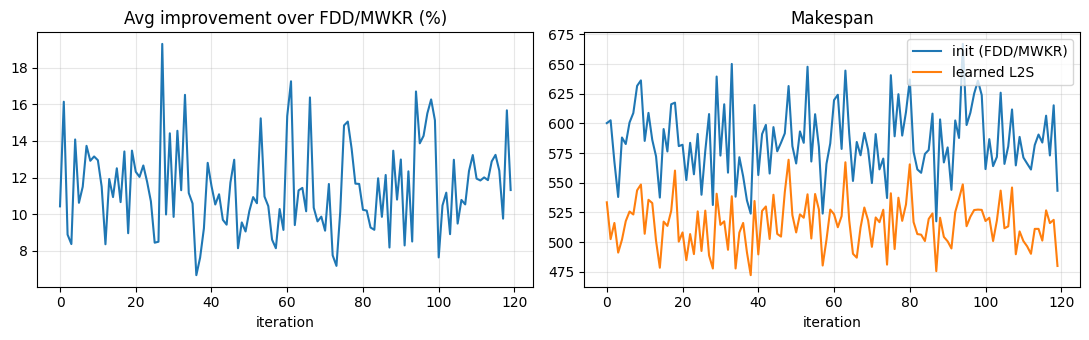

In [14]:
# Cell 13 — Train on 6x6 (Colab Free Tier default: ~3-5 min on CPU)
cfg = Config(n_jobs=6, n_machines=6, horizon_T=64, n_step=8,
             batch_size=8, n_iterations=120, lr=5e-4, embed_dim=64, n_layers=3, gat_heads=4)
set_seed(cfg.seed)
t0 = time.time()
policy, history = train(cfg, log_every=10)
print(f"Training done in {time.time()-t0:.1f}s")

save_checkpoint(policy, cfg)
policy = load_checkpoint(cfg.ckpt_path, cfg, DEVICE)
print("checkpoint reloaded OK")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history["iter"], history["impr%"])
ax[0].set_title("Avg improvement over FDD/MWKR (%)"); ax[0].set_xlabel("iteration"); ax[0].grid(alpha=.3)
ax[1].plot(history["iter"], history["init_mk"], label="init (FDD/MWKR)")
ax[1].plot(history["iter"], history["final_mk"], label="learned L2S")
ax[1].set_title("Makespan"); ax[1].set_xlabel("iteration"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


In [15]:
# Cell 13b — Curriculum training: fine-tune on progressively larger instances
#
# The GNN is size-agnostic (no fixed-size layers), so the 6x6-trained policy can be
# fine-tuned on larger instances without architectural changes. Each stage loads the
# previous checkpoint and continues training with a smaller lr and fewer iterations
# to stay within Colab Free Tier time limits.
#
# Estimated wall-clock times on Colab Free Tier (CPU):
#   15x15 : ~4-6 min   |  20x20 : ~6-9 min
#   30x30 : ~10-15 min |  50x20 : ~8-12 min
# On a T4 GPU these are 3-5x faster.
#
# Set RUN_CURRICULUM = True to execute. Skipped by default to keep Run-All fast.

RUN_CURRICULUM = False   # <-- set True to run

CURRICULUM_STAGES = [
    # (J,  M,  horizon, batch, iters,  lr,    ckpt_suffix)
    (15, 15,  80,      4,     60,    2e-4,  "15x15"),
    (20, 20,  96,      4,     50,    1e-4,  "20x20"),
    (30, 30,  128,     2,     30,    5e-5,  "30x30"),
    (50, 20,  128,     2,     30,    5e-5,  "50x20"),
]

if RUN_CURRICULUM:
    cur_policy = policy   # start from the 6x6 checkpoint
    for J, M, hT, bs, iters, lr, suffix in CURRICULUM_STAGES:
        print(f"\n{'='*55}")
        print(f"Curriculum stage: {J}x{M}  horizon={hT}  batch={bs}  iters={iters}")
        print(f"{'='*55}")
        stage_cfg = Config(
            n_jobs=J, n_machines=M,
            horizon_T=hT, n_step=8, batch_size=bs, n_iterations=iters,
            lr=lr, embed_dim=cfg.embed_dim, gin_hidden=cfg.gin_hidden,
            gat_hidden=cfg.gat_hidden, gat_heads=cfg.gat_heads,
            n_layers=cfg.n_layers, act_hidden=cfg.act_hidden, act_dim=cfg.act_dim,
            entropy_coef=0.005, value_coef=0.5, grad_clip=1.0,
            seed=cfg.seed + 1,
            ckpt_path=f"l2s_jssp_policy_{suffix}.pt"
        )
        t0 = time.time()
        cur_policy, stage_hist = train(stage_cfg, policy=cur_policy, log_every=10)
        print(f"Stage {suffix} done in {time.time()-t0:.1f}s")
        save_checkpoint(cur_policy, stage_cfg)
        # quick plot
        plt.figure(figsize=(6, 2.5))
        plt.plot(stage_hist["iter"], stage_hist["impr%"])
        plt.title(f"Curriculum {suffix}: improvement over FDD/MWKR")
        plt.xlabel("iteration"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
    policy = cur_policy   # use the curriculum-trained policy for evaluation
    print("\nCurriculum training complete. Using curriculum policy for evaluation.")
else:
    print("Curriculum training skipped (RUN_CURRICULUM=False).")
    print("Set RUN_CURRICULUM=True and re-run this cell to fine-tune on larger instances.")


Curriculum training skipped (RUN_CURRICULUM=False).
Set RUN_CURRICULUM=True and re-run this cell to fine-tune on larger instances.


In [16]:
# Cell 14 — Classic benchmark datasets: locate, load, and VERIFY the format

REPO_URL = "https://gitlab.com/thanhdo2404-group/demo-jssp-model.git"

DATA_DIR = None
for _cand in ("datasets", "../datasets", "demo-jssp-model/datasets",
              "/content/demo-jssp-model/datasets", "/content/drive/MyDrive/datasets"):
    if os.path.isdir(_cand):
        DATA_DIR = _cand; break
if DATA_DIR is None:
    os.system(f"git clone --depth 1 {REPO_URL}")
    if os.path.isdir("demo-jssp-model/datasets"):
        DATA_DIR = "demo-jssp-model/datasets"
print("DATA_DIR =", DATA_DIR)

_FOLDER = {"ft": "ft", "la": "la", "ab": "abz", "or": "orb",
           "sw": "swv", "ta": "ta", "yn": "yn"}

def load_benchmark(name):
    if DATA_DIR is None: return None
    folder = _FOLDER.get(name[:2])
    if folder is None: return None
    path = os.path.join(DATA_DIR, folder, name)
    if not os.path.isfile(path): return None
    with open(path) as f: return parse_standard_jssp(f.read())


# ---- format verification on ft06 (known optimum = 55) ----
inst = load_benchmark("ft06")
if inst is None:
    print("!! ft06 not found. See clone note above.")
else:
    assert inst.times.shape == (6, 6) and inst.machines.shape == (6, 6)
    for j in range(inst.J):
        assert sorted(inst.machines[j].tolist()) == list(range(inst.M)), f"job {j} not a permutation"
    assert (inst.times > 0).all()
    mk0 = makespan_of(inst, fdd_mwkr_initial(inst))
    assert mk0 >= 55
    print("ft06 parsed OK: shapes (6,6); every row of `machines` is a permutation of 0..5")
    print("machines[0] =", inst.machines[0], " times[0] =", inst.times[0])
    print(f"FDD/MWKR makespan = {mk0:.0f}  (known optimum = 55)")
    print("Dataset layout is consistent with times[j][i] / machines[j][i] convention.")


DATA_DIR = /content/drive/MyDrive/datasets
ft06 parsed OK: shapes (6,6); every row of `machines` is a permutation of 0..5
machines[0] = [2 0 1 3 5 4]  times[0] = [1. 3. 6. 7. 3. 6.]
FDD/MWKR makespan = 66  (known optimum = 55)
Dataset layout is consistent with times[j][i] / machines[j][i] convention.


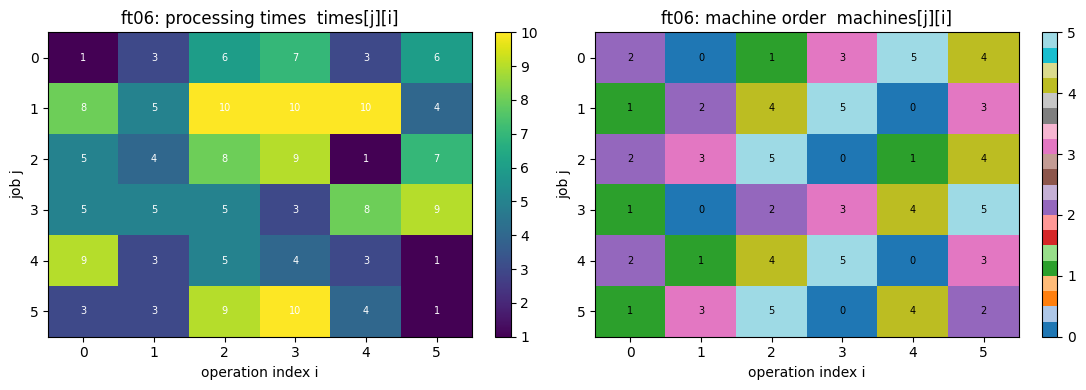

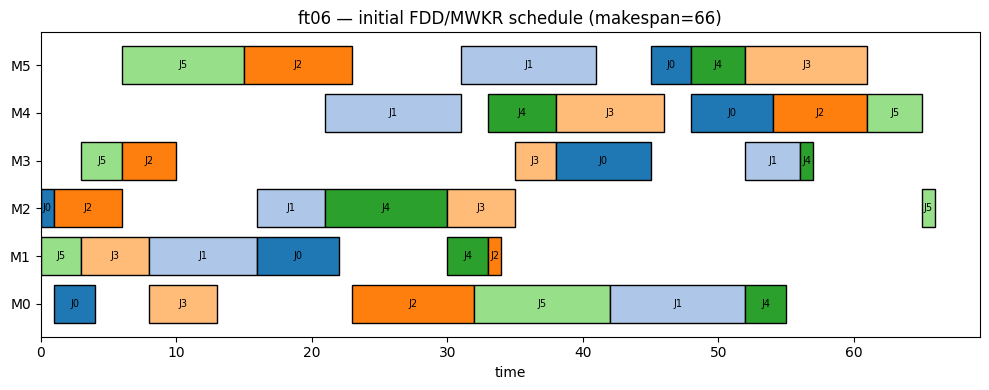

In [17]:
# Cell 15 — Visualize ft06: processing-time & machine-order heatmaps + Gantt
def plot_gantt(inst, machine_seq, title=""):
    preds, succs = build_graph(inst, machine_seq)
    est, lst, mk, _ = cpm_schedule(inst, preds, succs)
    cmap = plt.get_cmap("tab20")
    fig, ax = plt.subplots(figsize=(10, 0.5 * inst.M + 1))
    for m in range(inst.M):
        for o in machine_seq[m]:
            j = o // inst.M
            ax.barh(m, inst.p[o], left=est[o], color=cmap(j % 20), edgecolor="black")
            ax.text(est[o] + inst.p[o] / 2, m, f"J{j}",
                    va="center", ha="center", fontsize=7)
    ax.set_yticks(range(inst.M))
    ax.set_yticklabels([f"M{m}" for m in range(inst.M)])
    ax.set_xlabel("time")
    ax.set_title(f"{title} (makespan={mk:.0f})")
    plt.tight_layout(); plt.show()


def show_instance(inst, name=""):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    im0 = ax[0].imshow(inst.times, cmap="viridis", aspect="auto")
    ax[0].set_title(f"{name}: processing times  times[j][i]")
    ax[0].set_xlabel("operation index i"); ax[0].set_ylabel("job j")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)
    im1 = ax[1].imshow(inst.machines, cmap="tab20", aspect="auto")
    ax[1].set_title(f"{name}: machine order  machines[j][i]")
    ax[1].set_xlabel("operation index i"); ax[1].set_ylabel("job j")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)
    if inst.J <= 12 and inst.M <= 12:
        for j in range(inst.J):
            for i in range(inst.M):
                ax[0].text(i, j, int(inst.times[j, i]),
                           ha="center", va="center", color="white", fontsize=7)
                ax[1].text(i, j, int(inst.machines[j, i]),
                           ha="center", va="center", color="black", fontsize=7)
    plt.tight_layout(); plt.show()


if inst is not None:
    show_instance(inst, "ft06")
    plot_gantt(inst, fdd_mwkr_initial(inst), title="ft06 — initial FDD/MWKR schedule")


In [18]:
# Cell 16 — L2S solver: greedy rollout OR best-of-k stochastic sampling
#
# solve(policy, inst, steps, greedy=True)          : single greedy rollout
# solve(policy, inst, steps, greedy=False,
#       n_samples=k, seeds=range(k))               : k stochastic rollouts, return best
#
# Multi-sample evaluation is more expensive but significantly improves results on
# large instances where the greedy policy may get stuck in local optima.
# On Colab Free Tier, use n_samples=3-5 for medium instances, 1-2 for large ones.

@torch.no_grad()
def solve(policy, inst, steps=300, greedy=True, n_samples=1, seeds=None):
    '''Solve one instance.
    If greedy=True or n_samples=1: single deterministic rollout.
    If greedy=False and n_samples>1: run n_samples stochastic rollouts with
    different seeds and return the best makespan found across all runs.
    '''
    if seeds is None:
        seeds = list(range(n_samples))
    run_cfg = Config(horizon_T=10**9)

    def _one_rollout(seed, use_greedy):
        env = Environment(inst, run_cfg, random.Random(seed))
        st = env.reset()
        for _ in range(steps):
            if env.done or not st["cands"]: break
            move, _, _, _ = select_action(policy, st, DEVICE, greedy=use_greedy)
            st, _, _ = env.step(move)
        return env.init_makespan, env.best_makespan

    if greedy or n_samples <= 1:
        init_mk, best_mk = _one_rollout(seeds[0], greedy)
        return init_mk, best_mk

    # multi-sample: stochastic rollouts
    init_mk = None; best_mk = float("inf")
    for s in seeds[:n_samples]:
        i_mk, b_mk = _one_rollout(s, use_greedy=False)
        if init_mk is None: init_mk = i_mk
        if b_mk < best_mk: best_mk = b_mk
    return init_mk, best_mk


instance     size    SPT    LPT    FDD   MWKR    SBT   L2S-g   L2S-s   gap%    opt     t
ft06         6x6      88     77     70     61     65      61      55   -9.8     55 24.8s
ft10        10x10   1074   1295   1090   1108   1252    1242    1021   -4.9    930 26.8s
ft20        20x5    1267   1631   1294   1501   1408    1696    1312   +3.6   1165 29.1s
la01        10x5     751    822    748    735    807     740     666   -9.4    666 25.5s
la16        10x10   1156   1229   1062   1054   1164    1156     988   -6.3    945 21.7s
la21        15x10   1324   1451   1253   1264   1303    1488    1121  -10.5   1046 15.4s
abz5        10x10   1352   1586   1363   1369   1421    1395    1284   -5.0   1234 21.8s
ta01        15x15   1462   1701   1439   1491   1827    1722    1377   -4.3   1231 12.7s
la31        30x10   1951   2245   1895   1931   2638    2163    1847   -2.5   1784  7.9s
ta31        30x15   2335   2417   2240   2134   3203    2467    2206   +3.4   1764  7.8s
ta51        50x15   3

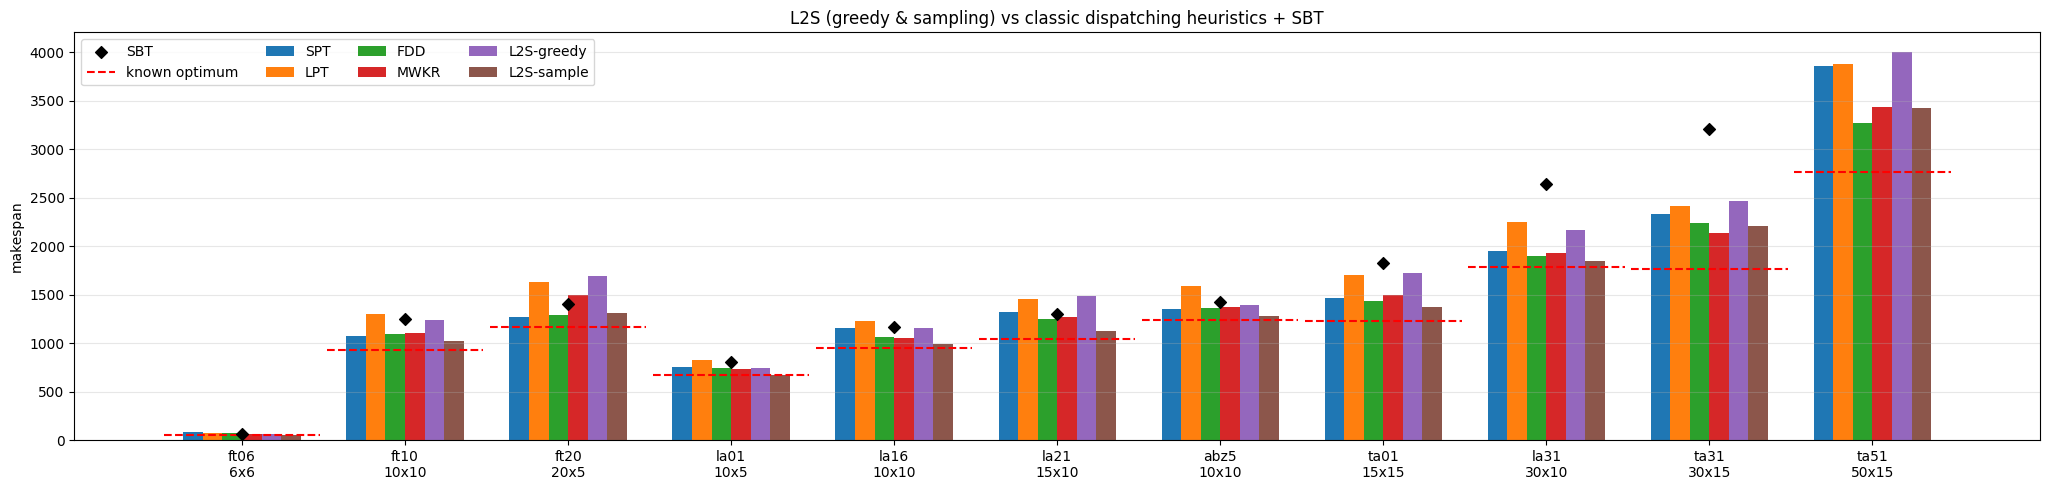

In [19]:
# Cell 17 — Benchmark comparison: L2S (greedy + sampling) vs SPT/LPT/FDD/MWKR/SBT
#
# METHODS compared:
#   SPT, LPT, FDD, MWKR  : non-delay dispatching rules
#   SBT                   : Shifting Bottleneck Heuristic
#   L2S-greedy            : single greedy rollout of the trained policy
#   L2S-sample            : best of N_SAMPLES stochastic rollouts
#
# All methods share the same CPM evaluator (makespan_of) for fair comparison.
# SBT is skipped on very large instances (>30 jobs) to stay within time limits.

KNOWN_OPT = {"ft06": 55, "ft10": 930, "ft20": 1165,
             "la01": 666, "la16": 945, "la21": 1046, "la31": 1784,
             "abz5": 1234, "ta01": 1231, "ta31": 1764, "ta51": 2760}

# (instance, L2S step budget, n_samples for stochastic eval)
BENCHMARKS = [
    ("ft06",  300, 5),
    ("ft10",  300, 5),
    ("ft20",  300, 5),
    ("la01",  300, 5),
    ("la16",  300, 4),
    ("la21",  250, 3),
    ("abz5",  300, 4),
    ("ta01",  200, 3),
    ("la31",  150, 2),
    ("ta31",  120, 2),
    ("ta51",  100, 1),
]
METHODS = ["SPT", "LPT", "FDD", "MWKR", "SBT", "L2S-greedy", "L2S-sample"]
SBT_MAX_JOBS = 30   # skip SBT on instances larger than this (too slow on CPU)

results = []
hdr = (f"{'instance':9s}{'size':>8s}{'SPT':>7s}{'LPT':>7s}{'FDD':>7s}"
       f"{'MWKR':>7s}{'SBT':>7s}{'L2S-g':>8s}{'L2S-s':>8s}{'gap%':>7s}{'opt':>7s}{'t':>6s}")
print(hdr)
for name, budget, n_samp in BENCHMARKS:
    bi = load_benchmark(name)
    if bi is None:
        print(f"{name:9s}  -- not found, skipped --")
        continue
    t0 = time.time()
    mks = {}
    for rule in ("SPT", "LPT", "FDD", "MWKR"):
        mks[rule] = makespan_of(bi, heuristic_dispatch(bi, rule))
    if bi.J <= SBT_MAX_JOBS:
        mks["SBT"] = makespan_of(bi, shifting_bottleneck(bi))
    else:
        mks["SBT"] = float("nan")   # too slow
    _, mks["L2S-greedy"] = solve(policy, bi, steps=budget, greedy=True)
    _, mks["L2S-sample"] = solve(policy, bi, steps=budget, greedy=False,
                                  n_samples=n_samp, seeds=list(range(n_samp)))
    heur_vals = [mks[m] for m in ("SPT", "LPT", "FDD", "MWKR", "SBT")
                 if not (isinstance(mks[m], float) and np.isnan(mks[m]))]
    best_h = min(heur_vals)
    gap = 100.0 * (mks["L2S-sample"] - best_h) / best_h
    opt = KNOWN_OPT.get(name)
    results.append({"name": name, "size": f"{bi.J}x{bi.M}", **mks,
                    "gap": gap, "opt": opt})
    sbt_str = f"{mks['SBT']:7.0f}" if not np.isnan(mks['SBT']) else "    n/a"
    print(f"{name:9s}{bi.J:>5d}x{bi.M:<2d}"
          f"{mks['SPT']:>7.0f}{mks['LPT']:>7.0f}{mks['FDD']:>7.0f}{mks['MWKR']:>7.0f}"
          f"{sbt_str}{mks['L2S-greedy']:>8.0f}{mks['L2S-sample']:>8.0f}"
          f"{gap:>+7.1f}{(str(opt) if opt else '-'):>7s}{time.time()-t0:>5.1f}s")

# ---- grouped bar chart ----
if results:
    plot_methods = [m for m in METHODS if m != "SBT"]   # SBT may have NaN
    x = np.arange(len(results)); w = 0.12
    fig, ax = plt.subplots(figsize=(1.6 * len(results) + 3, 5))
    for k, mth in enumerate(plot_methods):
        vals = [r[mth] if not (isinstance(r[mth], float) and np.isnan(r[mth]))
                else None for r in results]
        ax.bar(x + (k - len(plot_methods) / 2 + 0.5) * w,
               [v if v else 0 for v in vals], w, label=mth)
    # SBT as scatter (only where available)
    for xi, r in zip(x, results):
        if not np.isnan(r["SBT"]):
            ax.scatter(xi, r["SBT"], marker="D", color="black", zorder=5,
                       label="SBT" if xi == x[0] else None)
    opt_drawn = False
    for xi, r in zip(x, results):
        if r["opt"]:
            ax.hlines(r["opt"], xi - 4 * w, xi + 4 * w, colors="red", linestyles="--",
                      label="known optimum" if not opt_drawn else None)
            opt_drawn = True
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['name']}\n{r['size']}" for r in results])
    ax.set_ylabel("makespan")
    ax.set_title("L2S (greedy & sampling) vs classic dispatching heuristics + SBT")
    ax.legend(ncol=4); ax.grid(alpha=.3, axis="y")
    plt.tight_layout(); plt.show()


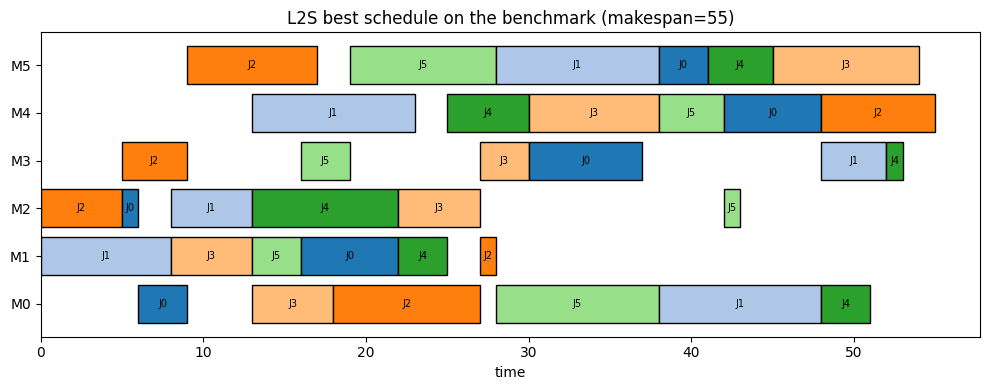

In [21]:
# Cell 18 — Gantt chart of the best schedule found by L2S on a benchmark instance
@torch.no_grad()
def best_schedule(policy, inst, steps=300, seed=0):
    run_cfg = Config(horizon_T=10**9)
    env = Environment(inst, run_cfg, random.Random(seed))
    st = env.reset()
    best_seq = [list(s) for s in env.machine_seq]; best = env.best_makespan
    for _ in range(steps):
        if env.done or not st["cands"]: break
        move, _, _, _ = select_action(policy, st, DEVICE, greedy=False)
        st, r, done = env.step(move)
        if env.makespan <= best:
            best = env.makespan
            best_seq = [list(s) for s in env.machine_seq]
    return best_seq, best


_gantt_inst = load_benchmark("ft06")
if _gantt_inst is not None:
    seq, mk = best_schedule(policy, _gantt_inst, steps=300, seed=0)
    plot_gantt(_gantt_inst, seq, title="L2S best schedule on the benchmark")
else:
    print("benchmark instance not available - skipping Gantt")


## Notes, tips & how to scale up

**Make it stronger / closer to the paper.** Increase capacity and search budget in `Config`:
```python
cfg = Config(n_jobs=10, n_machines=10,
             embed_dim=128, gin_hidden=128, gat_hidden=128, gat_heads=8,
             n_layers=4, horizon_T=500, n_step=10, batch_size=64,
             lr=5e-5, n_iterations=2000)
```
Then re-run Cells 12-18. Use a **GPU runtime** for the larger settings.

**Curriculum training** (Cell 13b). Set `RUN_CURRICULUM = True` to fine-tune the
6×6-trained policy on 15×15 → 20×20 → 30×30 → 50×20. Each stage saves its own
checkpoint (`l2s_jssp_policy_15x15.pt`, etc.). On a T4 GPU the full curriculum
takes ~15-20 minutes; on CPU ~40-60 minutes.

**Multi-sample evaluation** (Cell 16). `solve(..., greedy=False, n_samples=k)` runs
`k` stochastic rollouts and returns the best makespan. This is the most effective
way to improve results on large instances without retraining. Recommended: `n_samples=5`
for medium instances, `n_samples=2-3` for large ones on the free tier.

**Checkpointing.** The trained policy is stored in `l2s_jssp_policy.pt`
(`save_checkpoint` / `load_checkpoint` in Cell 12). Download from the Colab file
browser to reuse without retraining.

**Differences vs. the paper (deliberate, for a runnable prototype):**
- Dense adjacency instead of `torch_geometric` sparse ops (fine for small/medium `N`).
  The conjunctive adjacency is built once; only the disjunctive part is rebuilt each step.
- **Multi-head GAT** (CAM) with `gat_heads=4` by default (paper uses single-head).
- **GPU message-passing** for both EST (forward) and LST (backward) as node features.
- **Actor-critic** (learned value baseline) instead of plain REINFORCE.
- **SBT** (Shifting Bottleneck) added as a strong constructive baseline.

**Where each L2S pillar lives:** loop=`Environment` (Cell 8), N5=Cell 6,
GIN/multi-head GAT=Cell 10, MDP/reward=Cell 8, GPU MP evaluator=Cell 5,
curriculum=Cell 13b, benchmarks & baselines=Cells 14-18.
